<a href="https://colab.research.google.com/github/Luca4Spreafico/CHALLENGE-2---Ibuprofen/blob/main/ML_Hybrid_SwinBase_CustomCNN_DualStream_5Fold_Ensemble_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AN2DL Second Challenge: Preprocessing & Modeling**
> ## ***Ibuprofen*** **Team**
>
> **Team Members:**
> * Angelo Notarnicola (279710)
> * Daniele Piano (249385)
> * Luca Spreafico (303871)
> * Michele Leggieri (244615)
>
> We have already run the previous notebook "AN2DL Second Challenge: Data Cleaning" in order to have the data cleaned.
This notebook contains the final pipeline that achieved our top score (0.4375). It implements the preprocessing, images modification, and the hybrid CNN-Swin Trasformer model architecture derived from our data analysis.


># **Super important:**
> The model and the file submission will be find inside the shared folder called on Google drive "/gdrive/My Drive/Luca cartella/??????"

> ## ***Cropping those images!***
>
> In order to reduce computational time we already cropped the images around the masks.

> ## Crop 512 * 512, overlap 128 * 128:
> These images are the input for the Swin Trasformer. The logic used for cropping is the following: Generate fixed-size square tiles (tile_size x tile_size) that best cover a given mask, using a greedy selection of tile positions + fallback for isolated leftovers. Then deduplicate tiles that cover exactly the same set of mask pixels, keeping only the best-centered tile in each group.

> ## Crop 144 * 144, overlap 64 * 64:
> The input for the Custom CNN consists of these images. The cropping approach is the same as that of the Transformer, but with two key differences: the tile size is changed to 144, and the mask is used in a different way. Specifically, we multiply the mask by the image and whiten the background. The resulting image is then cropped using the same logic as the 512 cropping process.

In [ ]:
# ==========================================
# 1. SETUP & DATA COPY
# ==========================================
!pip install -q timm lion-pytorch ranger21

import os
import shutil
import time
from google.colab import drive

# Mount Drive
drive.mount('/gdrive')

# --- CONFIGURATION FOR COPY ---
DRIVE_ROOT = "/gdrive/My Drive/Luca cartella"

# Source Paths (In Google Drive)
SRC_TRAIN_512 = os.path.join(DRIVE_ROOT, "train_data_crops_crop512_ov128")
SRC_TRAIN_144 = os.path.join(DRIVE_ROOT, "train_crops_144_ov64")
SRC_TEST_512  = os.path.join(DRIVE_ROOT, "organized_data/test_crops_512_ov128")
SRC_TEST_144  = os.path.join(DRIVE_ROOT, "test_crops_144_ov64")

# Destination Paths (Local Colab Runtime - FAST)
LOCAL_ROOT = "/content/data"
LOC_TRAIN_512 = os.path.join(LOCAL_ROOT, "train_512")
LOC_TRAIN_144 = os.path.join(LOCAL_ROOT, "train_144")
LOC_TEST_512  = os.path.join(LOCAL_ROOT, "test_512")
LOC_TEST_144  = os.path.join(LOCAL_ROOT, "test_144")

def fast_copy(source, dest):
    if os.path.exists(dest):
        print(f"✅ {dest} exists. Skipping copy.")
        return
    if not os.path.exists(source):
        print(f"❌ Source not found: {source}")
        return

    print(f"🚀 Copying {os.path.basename(source)} to local disk...")
    start = time.time()
    # Using system cp is faster than python shutil
    !cp -r "{source}" "{dest}"
    print(f"   -> Done in {time.time()-start:.1f}s")

# Execute Copy
os.makedirs(LOCAL_ROOT, exist_ok=True)
fast_copy(SRC_TRAIN_512, LOC_TRAIN_512)
fast_copy(SRC_TRAIN_144, LOC_TRAIN_144)
fast_copy(SRC_TEST_512, LOC_TEST_512)
fast_copy(SRC_TEST_144, LOC_TEST_144)

print("\n✅ Data is now local. Training will be fast.")

Mounted at /gdrive
🚀 Copying train_data_crops_crop512_ov128 to local disk...
   -> Done in 0.1s
🚀 Copying train_crops_144_ov64 to local disk...
   -> Done in 0.1s
🚀 Copying test_crops_512_ov128 to local disk...
   -> Done in 40.0s
🚀 Copying test_crops_144_ov64 to local disk...
   -> Done in 0.1s

✅ Data is now local. Training will be fast.




Epochs: We set the number of epochs to 16. This value was chosen because we empirically observed no significant improvement beyond this point.

Batch Size: A batch size of 16 yielded the best results after extensive testing and experimentation.Input Resolution: An input resolution of $384 \times 384$ is necessary for the Swin Transformer. While we initially tested a cropping of $318 \times 318$, the model performed optimally with a resolution of $512 \times 512$.

Cross-Validation: 5-fold cross-validation was used for model assessment, which is a standard practice in the field.

**LABEL PRESENCE Analysis:** Slight Imbalance (`Luminal A` ~27.2%, `Luminal B` ~35.1%, `HER2(+)` ~25.8%, `Triple Negative` ~11.9%).
* **Actions:** Validation Split: 20% of the training set was selected for validation, ensuring a balanced representation of all classes (or labels).



In [ ]:
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from collections import defaultdict

class Config:
    # We use Drive only for saving outputs now
    DRIVE_SAVE_DIR = "/gdrive/My Drive/Luca cartella"

    # INPUTS (Local Paths from Cell 1)
    TRAIN_DIR_512 = "/content/data/train_512"
    TRAIN_DIR_144 = "/content/data/train_144"
    TEST_DIR_512 = "/content/data/test_512"
    TEST_DIR_144 = "/content/data/test_144"

    # Labels (Read directly from Drive is fine for single CSV)
    LABELS_PATH = os.path.join(DRIVE_SAVE_DIR, "train_labels_crops_crop144_ov64.csv")

    # OUTPUTS
    OUTPUT_DIR = os.path.join(DRIVE_SAVE_DIR, "models_kfold_final")
    SUBMISSION_FILE = os.path.join(DRIVE_SAVE_DIR, "submission_ensemble.csv")

    # HYPERPARAMETERS
    N_FOLDS = 5
    EPOCHS = 15
    BATCH_SIZE = 16
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-4
    SEED = 42
    # Since data is local, we can use workers!
    NUM_WORKERS = 2

    RESIZE_SWIN = 384
    RESIZE_CNN = 144

    LABEL_MAP = {'Luminal A': 0, 'Luminal B': 1, 'HER2(+)': 2, 'Triple negative': 3}
    IDX_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}

os.makedirs(Config.OUTPUT_DIR, exist_ok=True)

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(Config.SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Config Ready. Outputting to: {Config.OUTPUT_DIR}")

✅ Config Ready. Outputting to: /gdrive/My Drive/Luca cartella/models_kfold_final


**DualPathDataset class**

This section implements a custom PyTorch dataset that feeds our hybrid dual-path architecture. The dataset handles images at two different resolutions simultaneously.

Transform pipelines apply ImageNet normalization to both paths (required for pretrained models) and include standard augmentation during training: random flips, rotations, and color jitter to improve generalization. Validation and test transforms skip augmentation, applying only resizing and normalization.

In [ ]:
class DualPathDataset(Dataset):
    def __init__(self, df, dir_512, dir_144, transform_512=None, transform_144=None, is_train=True):
        self.dir_512 = dir_512
        self.dir_144 = dir_144
        self.transform_512 = transform_512
        self.transform_144 = transform_144
        self.is_train = is_train
        self.data = []

        for idx, row in df.iterrows():
            fname_base = row['sample_index']

            if self.is_train:
                # TRAIN MAPPING:
                # 144: img_0000_crop000.png
                # 512: img_0000_000.png
                f144 = fname_base
                f512 = fname_base.replace('_crop', '_')
            else:
                # TEST MAPPING:
                # Both are img_0000_000.png
                f144 = fname_base
                f512 = fname_base

            p144 = os.path.join(self.dir_144, f144)
            p512 = os.path.join(self.dir_512, f512)

            if os.path.exists(p144) and os.path.exists(p512):
                entry = {
                    'p144': p144,
                    'p512': p512,
                    # ID for grouping
                    'orig_id': f144.split('_')[0] + "_" + f144.split('_')[1]
                }
                if self.is_train:
                    entry['label'] = Config.LABEL_MAP[row['label']]
                else:
                    entry['sample_index'] = f144
                self.data.append(entry)

        if is_train:
            print(f"   -> Loaded {len(self.data)} valid pairs.")

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        entry = self.data[idx]
        try:
            img512 = Image.open(entry['p512']).convert('RGB')
            img144 = Image.open(entry['p144']).convert('RGB')

            if self.transform_512: img512 = self.transform_512(img512)
            if self.transform_144: img144 = self.transform_144(img144)

            if self.is_train:
                return img512, img144, torch.tensor(entry['label'], dtype=torch.long)
            else:
                return img512, img144, entry['sample_index']
        except:
            # Fallback
            return torch.zeros(3,384,384), torch.zeros(3,144,144), 0

def get_transforms(augment=True):
    norm = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    if augment:
        aug = transforms.Compose([
            transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
            transforms.RandomRotation(20), transforms.ColorJitter(0.1, 0.1, 0.1, 0.05),
            transforms.ToTensor(), norm
        ])
        t512 = transforms.Compose([transforms.Resize((Config.RESIZE_SWIN, Config.RESIZE_SWIN)), aug])
        t144 = transforms.Compose([transforms.Resize((Config.RESIZE_CNN, Config.RESIZE_CNN)), aug])
    else:
        base = transforms.Compose([transforms.ToTensor(), norm])
        t512 = transforms.Compose([transforms.Resize((Config.RESIZE_SWIN, Config.RESIZE_SWIN)), base])
        t144 = transforms.Compose([transforms.Resize((Config.RESIZE_CNN, Config.RESIZE_CNN)), base])
    return t512, t144

FUSION: The two feature streams are concatenated and fed through a fusion head with dropout regularization for final classification.

In [ ]:
class DualPathModel(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.swin = timm.create_model('swin_base_patch4_window12_384', pretrained=True, num_classes=0, global_pool='avg')
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 64, 7, 2, 3), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(3, 2, 1),
            self._block(64, 128), self._block(128, 256), self._block(256, 512),
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten()
        )
        self.fusion = nn.Sequential(
            nn.Linear(self.swin.num_features + 512, 768), nn.BatchNorm1d(768), nn.ReLU(True), nn.Dropout(0.4),
            nn.Linear(768, 256), nn.ReLU(True), nn.Dropout(0.2), nn.Linear(256, num_classes)
        )
    def _block(self, in_c, out_c):
        return nn.Sequential(nn.Conv2d(in_c, out_c, 3, 2, 1), nn.BatchNorm2d(out_c), nn.ReLU(True),
                             nn.Conv2d(out_c, out_c, 3, 1, 1), nn.BatchNorm2d(out_c), nn.ReLU(True))
    def forward(self, x512, x144):
        return self.fusion(torch.cat([self.swin(x512), self.cnn(x144)], dim=1))

In [ ]:
def train_epoch(model, loader, criterion, opt, scaler):
    model.train()
    loss_sum, corr, count = 0, 0, 0
    # leave=False keeps output minimal
    for x512, x144, y in tqdm(loader, leave=False, desc="Train"):
        x512, x144, y = x512.to(device), x144.to(device), y.to(device)
        opt.zero_grad()
        with autocast():
            pred = model(x512, x144)
            loss = criterion(pred, y)
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        loss_sum += loss.item() * y.size(0)
        corr += (pred.argmax(1) == y).sum().item()
        count += y.size(0)
    return loss_sum/count, corr/count

@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    loss_sum, corr, count = 0, 0, 0
    preds, labels = [], []
    for x512, x144, y in tqdm(loader, leave=False, desc="Val"):
        x512, x144, y = x512.to(device), x144.to(device), y.to(device)
        with autocast():
            pred = model(x512, x144)
            loss = criterion(pred, y)
        loss_sum += loss.item() * y.size(0)
        corr += (pred.argmax(1) == y).sum().item()
        count += y.size(0)
        preds.extend(pred.argmax(1).cpu().numpy())
        labels.extend(y.cpu().numpy())
    f1 = f1_score(labels, preds, average='weighted')
    return loss_sum/count, corr/count, f1

def plot_history(history, fold_num):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Loss
    ax1.plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
    ax1.plot(epochs, history['val_loss'], 'r-s', label='Val Loss')
    ax1.set_title(f'Fold {fold_num} - Loss Curve')
    ax1.set_xlabel('Epochs'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(True)

    # Metrics
    ax2.plot(epochs, history['val_acc'], 'g-o', label='Val Acc')
    ax2.plot(epochs, history['val_f1'], 'purple', label='Val F1 (Weighted)', marker='x')
    ax2.set_title(f'Fold {fold_num} - Validation Metrics')
    ax2.set_xlabel('Epochs'); ax2.set_ylabel('Score')
    ax2.legend(); ax2.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(Config.OUTPUT_DIR, f"fold_{fold_num}_history.png"))
    plt.show()

🚀 Starting 5-Fold Training...

STARTING FOLD 1/5
   -> Loaded 1488 valid pairs.
   -> Loaded 342 valid pairs.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/365M [00:00<?, ?B/s]

Epoch  | Train Loss |  Val Loss  |  Val Acc   |   Val F1  
------------------------------------------------------------


/tmp/ipython-input-2382041928.py:31: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


...

Train:   0%|          | 0/93 [00:00<?, ?it/s]

/tmp/ipython-input-2621377298.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Val:   0%|          | 0/22 [00:00<?, ?it/s]

/tmp/ipython-input-2621377298.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  15   |   0.4615   |   2.0336   |   0.3304   |   0.3204  


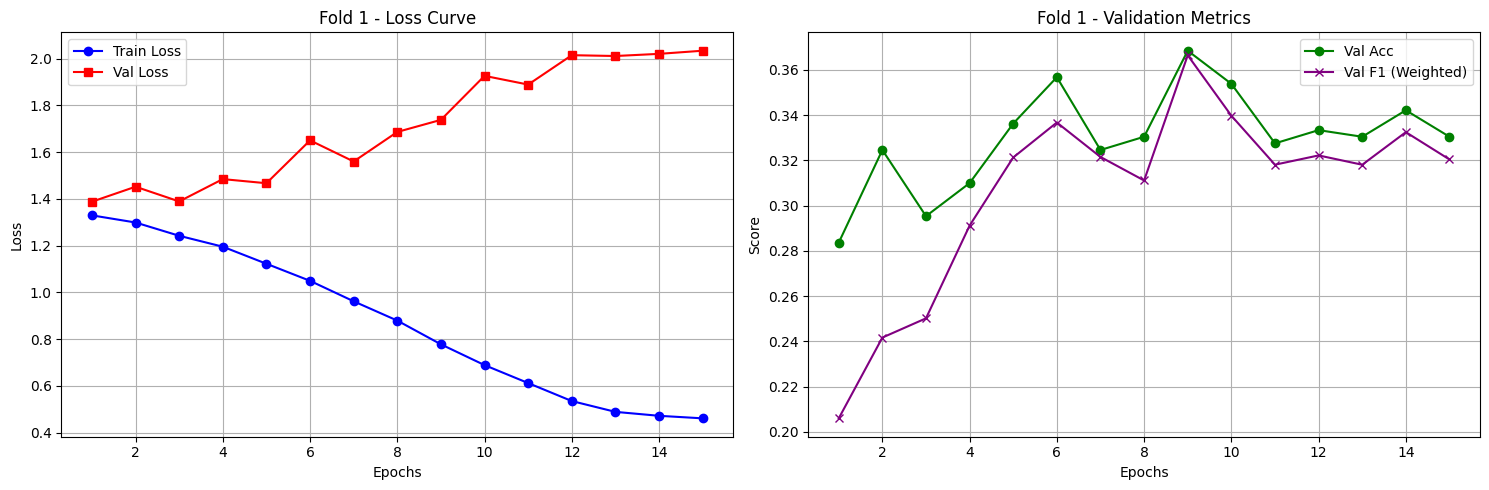


STARTING FOLD 2/5
   -> Loaded 1462 valid pairs.
   -> Loaded 368 valid pairs.
Epoch  | Train Loss |  Val Loss  |  Val Acc   |   Val F1  
------------------------------------------------------------


/tmp/ipython-input-2382041928.py:31: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Train:   0%|          | 0/92 [00:00<?, ?it/s]

/tmp/ipython-input-2621377298.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Val:   0%|          | 0/23 [00:00<?, ?it/s]

...

Train:   0%|          | 0/92 [00:00<?, ?it/s]

/tmp/ipython-input-2621377298.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x798989f6e0c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x798989f6e0c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-pac

Val:   0%|          | 0/23 [00:00<?, ?it/s]

/tmp/ipython-input-2621377298.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  15   |   0.7798   |   1.4039   |   0.4348   |   0.4334  


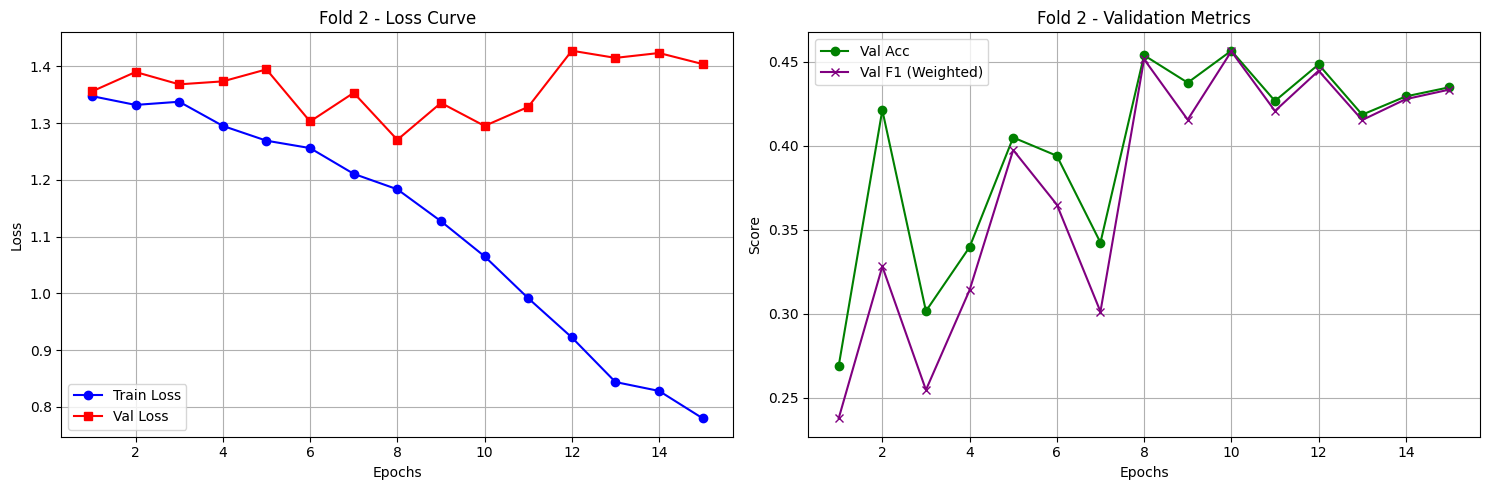


STARTING FOLD 3/5
   -> Loaded 1451 valid pairs.
   -> Loaded 379 valid pairs.
Epoch  | Train Loss |  Val Loss  |  Val Acc   |   Val F1  
------------------------------------------------------------


/tmp/ipython-input-2382041928.py:31: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Train:   0%|          | 0/91 [00:00<?, ?it/s]

/tmp/ipython-input-2621377298.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Val:   0%|          | 0/24 [00:00<?, ?it/s]

...

Train:   0%|          | 0/91 [00:00<?, ?it/s]

/tmp/ipython-input-2621377298.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x798989f6e0c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x798989f6e0c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-pac

Val:   0%|          | 0/24 [00:00<?, ?it/s]

/tmp/ipython-input-2621377298.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  15   |   0.7459   |   1.5194   |   0.3773   |   0.3785  


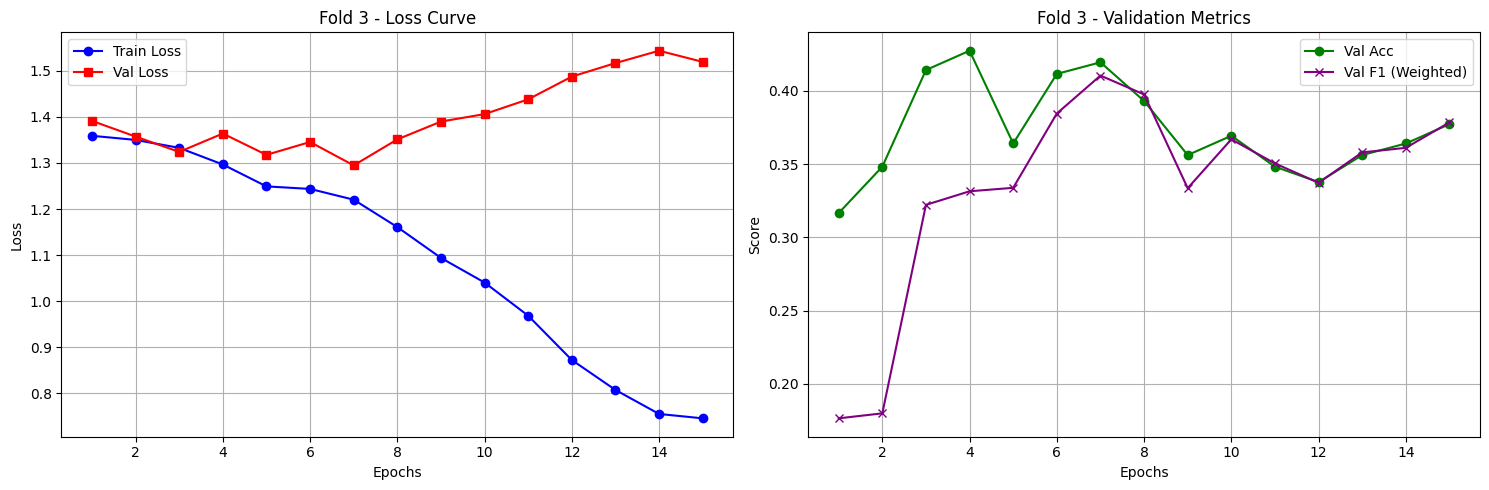


STARTING FOLD 4/5
   -> Loaded 1485 valid pairs.
   -> Loaded 345 valid pairs.
Epoch  | Train Loss |  Val Loss  |  Val Acc   |   Val F1  
------------------------------------------------------------


/tmp/ipython-input-2382041928.py:31: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Train:   0%|          | 0/93 [00:00<?, ?it/s]

/tmp/ipython-input-2621377298.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Val:   0%|          | 0/22 [00:00<?, ?it/s]

...

Train:   0%|          | 0/93 [00:00<?, ?it/s]

/tmp/ipython-input-2621377298.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Val:   0%|          | 0/22 [00:00<?, ?it/s]

/tmp/ipython-input-2621377298.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  15   |   0.6389   |   1.5247   |   0.4000   |   0.3952  


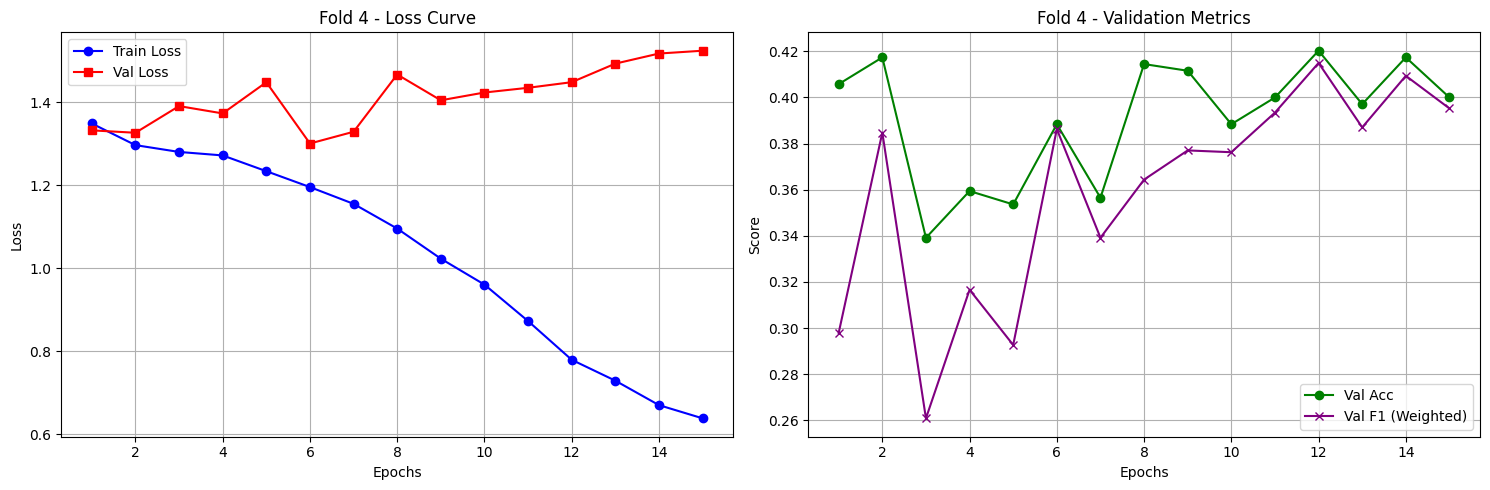


STARTING FOLD 5/5
   -> Loaded 1434 valid pairs.
   -> Loaded 396 valid pairs.
Epoch  | Train Loss |  Val Loss  |  Val Acc   |   Val F1  
------------------------------------------------------------


/tmp/ipython-input-2382041928.py:31: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Train:   0%|          | 0/90 [00:00<?, ?it/s]

/tmp/ipython-input-2621377298.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Val:   0%|          | 0/25 [00:00<?, ?it/s]

...

Train:   0%|          | 0/90 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x798989f6e0c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
   Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x798989f6e0c0> 
 Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
 ^    ^self._shutdown_workers()^
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
^^    ^if w.is_alive():^
^ ^  ^ 
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
       ^^assert self._parent_pid == os.getpid(), 'can only test a child process'^^^
^ ^ ^^  ^ ^ ^ 
   File "/usr/li

Val:   0%|          | 0/25 [00:00<?, ?it/s]

/tmp/ipython-input-2621377298.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  15   |   0.9280   |   1.2880   |   0.4217   |   0.4122  


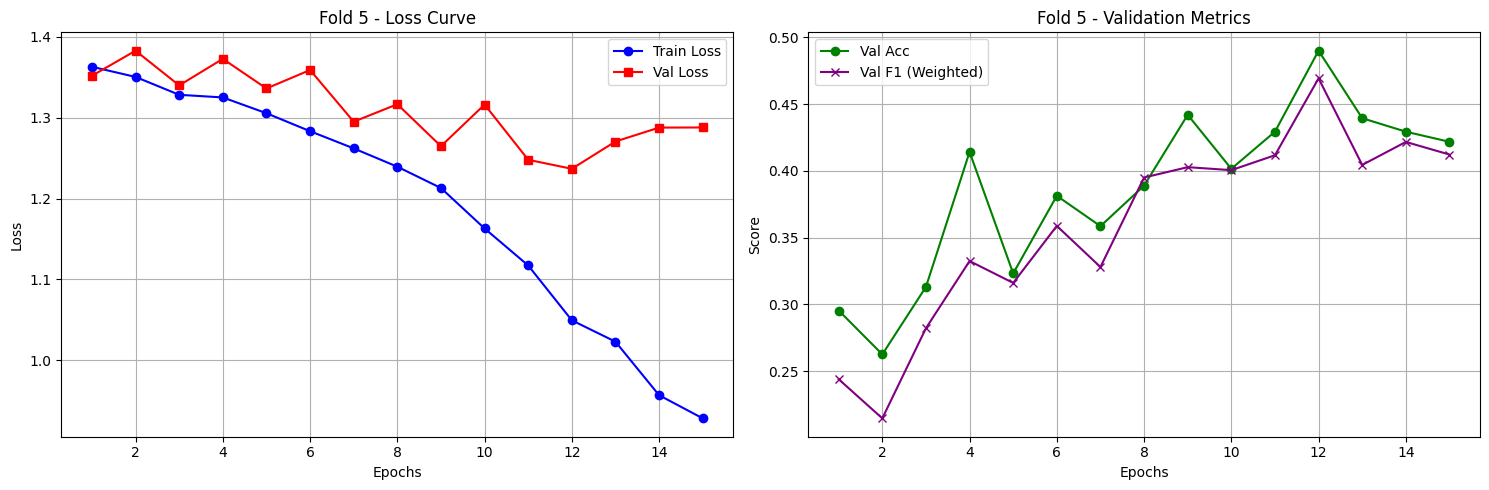

In [ ]:
# Load Labels
if not os.path.exists(Config.LABELS_PATH):
    raise RuntimeError(f"CSV not found at {Config.LABELS_PATH}")

df = pd.read_csv(Config.LABELS_PATH)
df['orig_id'] = df['sample_index'].apply(lambda x: x.split('_')[0] + "_" + x.split('_')[1])

print(f"🚀 Starting {Config.N_FOLDS}-Fold Training...")

sgkf = StratifiedGroupKFold(n_splits=Config.N_FOLDS, shuffle=True, random_state=Config.SEED)

for fold, (train_idx, val_idx) in enumerate(sgkf.split(df, df['label'], groups=df['orig_id'])):
    print(f"\n{'='*40}\nSTARTING FOLD {fold+1}/{Config.N_FOLDS}\n{'='*40}")

    save_path = os.path.join(Config.OUTPUT_DIR, f"model_fold_{fold+1}.pth")
    if os.path.exists(save_path):
        print("✅ Model exists. Skipping fold.")
        continue

    tf_train_512, tf_train_144 = get_transforms(True)
    tf_val_512, tf_val_144 = get_transforms(False)

    ds_train = DualPathDataset(df.iloc[train_idx], Config.TRAIN_DIR_512, Config.TRAIN_DIR_144, tf_train_512, tf_train_144)
    ds_val = DualPathDataset(df.iloc[val_idx], Config.TRAIN_DIR_512, Config.TRAIN_DIR_144, tf_val_512, tf_val_144)

    dl_train = DataLoader(ds_train, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=Config.NUM_WORKERS, pin_memory=True)
    dl_val = DataLoader(ds_val, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS, pin_memory=True)

    model = DualPathModel(num_classes=4).to(device)
    opt = optim.AdamW(model.parameters(), lr=Config.LEARNING_RATE, weight_decay=Config.WEIGHT_DECAY)
    scaler = GradScaler()
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=Config.EPOCHS)

    best_f1 = 0.0
    history = {'train_loss':[], 'val_loss':[], 'val_acc':[], 'val_f1':[]}

    # Table Header
    print(f"{'Epoch':^6} | {'Train Loss':^10} | {'Val Loss':^10} | {'Val Acc':^10} | {'Val F1':^10}")
    print("-" * 60)

    for ep in range(Config.EPOCHS):
        tl, tacc = train_epoch(model, dl_train, criterion, opt, scaler)
        vl, vacc, vf1 = validate(model, dl_val, criterion)
        scheduler.step()

        history['train_loss'].append(tl); history['val_loss'].append(vl)
        history['val_acc'].append(vacc); history['val_f1'].append(vf1)

        print(f"{ep+1:^6} | {tl:^10.4f} | {vl:^10.4f} | {vacc:^10.4f} | {vf1:^10.4f}")

        if vf1 > best_f1:
            best_f1 = vf1
            torch.save({'model_state_dict': model.state_dict(), 'f1': vf1}, save_path)

    plot_history(history, fold+1)
    del model, opt, scaler; torch.cuda.empty_cache()

In [ ]:
def run_inference():
    print("\n🚀 Starting Ensemble Inference...")

    if not os.path.exists(Config.TEST_DIR_144):
        print("❌ Test folder not found!")
        return

    test_files = sorted([f for f in os.listdir(Config.TEST_DIR_144) if f.endswith('.png')])
    test_df = pd.DataFrame({'sample_index': test_files, 'label': 'Luminal A'})

    tf_512, tf_144 = get_transforms(False)
    ds_test = DualPathDataset(test_df, Config.TEST_DIR_512, Config.TEST_DIR_144, tf_512, tf_144, is_train=False)
    dl_test = DataLoader(ds_test, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS)

    models = []
    for i in range(1, Config.N_FOLDS+1):
        path = os.path.join(Config.OUTPUT_DIR, f"model_fold_{i}.pth")
        if os.path.exists(path):
            m = DualPathModel(num_classes=4).to(device)
            m.load_state_dict(torch.load(path)['model_state_dict'])
            m.eval()
            models.append(m)

    if models:
        results = defaultdict(lambda: np.zeros(4))
        with torch.no_grad():
            for x512, x144, fnames in tqdm(dl_test):
                x512, x144 = x512.to(device), x144.to(device)
                avg_p = torch.zeros(x512.size(0), 4).to(device)
                for m in models:
                    with autocast(): avg_p += torch.softmax(m(x512, x144), dim=1)
                avg_p /= len(models)

                for fname, p in zip(fnames, avg_p.cpu().numpy()):
                    parts = fname.split('_')
                    orig_id = f"{parts[0]}_{parts[1]}.png"
                    results[orig_id] += p

        rows = [{'sample_index': k, 'label': Config.IDX_TO_LABEL[np.argmax(v)]} for k, v in results.items()]
        pd.DataFrame(rows).sort_values('sample_index').to_csv(Config.SUBMISSION_FILE, index=False)
        print(f"✅ Submission Saved: {Config.SUBMISSION_FILE}")
    else:
        print("❌ No models found.")

run_inference()


🚀 Starting Ensemble Inference...


  0%|          | 0/95 [00:00<?, ?it/s]

/tmp/ipython-input-2817090485.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): avg_p += torch.softmax(m(x512, x144), dim=1)


✅ Submission Saved: /gdrive/My Drive/Luca cartella/submission_ensemble.csv
